# OxfordIIITPet

In [13]:
import torch
import pickle as pkl
import numpy as np
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [14]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# should set download=True the first time 
train = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=False,
    transform=transform
)

test = OxfordIIITPet(
    root="./data",
    split="test",
    target_types="category",
    download=False,
    transform=transform
)

In [15]:
print(train)
print(test)

Dataset OxfordIIITPet
    Number of datapoints: 3680
    Root location: ./data
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=warn)
               ToTensor()
           )
Dataset OxfordIIITPet
    Number of datapoints: 3669
    Root location: ./data
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=warn)
               ToTensor()
           )


In [ ]:
train.classes

['Abyssinian',
 'American Bulldog',
 'American Pit Bull Terrier',
 'Basset Hound',
 'Beagle',
 'Bengal',
 'Birman',
 'Bombay',
 'Boxer',
 'British Shorthair',
 'Chihuahua',
 'Egyptian Mau',
 'English Cocker Spaniel',
 'English Setter',
 'German Shorthaired',
 'Great Pyrenees',
 'Havanese',
 'Japanese Chin',
 'Keeshond',
 'Leonberger',
 'Maine Coon',
 'Miniature Pinscher',
 'Newfoundland',
 'Persian',
 'Pomeranian',
 'Pug',
 'Ragdoll',
 'Russian Blue',
 'Saint Bernard',
 'Samoyed',
 'Scottish Terrier',
 'Shiba Inu',
 'Siamese',
 'Sphynx',
 'Staffordshire Bull Terrier',
 'Wheaten Terrier',
 'Yorkshire Terrier']

In [16]:
img, label = train[0]

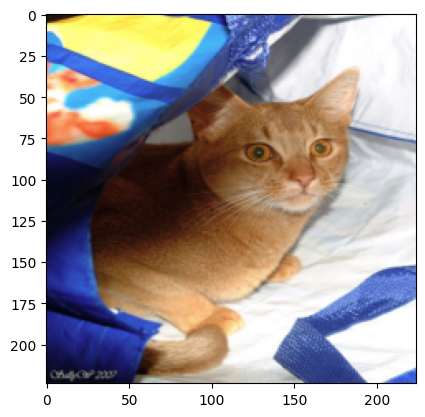

In [17]:
plt.imshow(img.permute(1, 2, 0))

In [18]:
train_x, train_y, test_x, test_y = [], [], [], []
for (_train_x, _train_y), (_test_x, _test_y) in zip(train, test):
    train_x.append(_train_x)
    train_y.append(_train_y)
    test_x.append(_test_x)
    test_y.append(_test_y)
     

In [19]:
print(f'Train : {len(train_x)} Text, {len(train_y)} Lebel / Test : {len(test_x)} Text, {len(test_y)} Label')

Train : 3669 Text, 3669 Lebel / Test : 3669 Text, 3669 Label


In [20]:
valid_x, test_x, valid_y, test_y = train_test_split(test_x, test_y, test_size = 0.5, stratify = test_y, random_state=42)

In [21]:
print('Train_y Distribution')
print(np.unique(train_y, return_counts = True), 'Sum', len(train_y), len(train_x))
print()
print('valid_y Distribution')
print(np.unique(valid_y, return_counts = True), 'Sum', len(valid_y), len(valid_x))
print()
print('Test_y Distribution')
print(np.unique(test_y, return_counts = True), 'Sum', len(test_y), len(test_x))

Train_y Distribution
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36]), array([100, 100, 100, 100, 100, 100, 100,  96, 100, 100, 100,  93,  96,
       100, 100, 100, 100, 100, 100, 100, 100, 100,  96, 100, 100, 100,
       100, 100, 100, 100, 100, 100,  99, 100, 100, 100,  89])) Sum 3669 3669

valid_y Distribution
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36]), array([49, 50, 50, 50, 50, 50, 50, 44, 49, 50, 50, 49, 50, 50, 50, 50, 50,
       50, 49, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 49, 50, 50, 50,
       45, 50, 50])) Sum 1834 1834

Test_y Distribution
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36]), array([49, 50

In [22]:
train_x, valid_x, test_x = torch.stack(train_x), torch.stack(valid_x), torch.stack(test_x)
train_y, valid_y, test_y = torch.tensor(train_y, dtype=torch.int8), torch.tensor(valid_y, dtype=torch.int8), torch.tensor(test_y, dtype=torch.int8)

In [23]:
with open('./OxfordIIITPet_preprocessed.pkl', 'wb') as f:
    pkl.dump([train_x, train_y, valid_x, valid_y, test_x, test_y], f, protocol=pkl.HIGHEST_PROTOCOL)

['Abyssinian',
 'American Bulldog',
 'American Pit Bull Terrier',
 'Basset Hound',
 'Beagle',
 'Bengal',
 'Birman',
 'Bombay',
 'Boxer',
 'British Shorthair',
 'Chihuahua',
 'Egyptian Mau',
 'English Cocker Spaniel',
 'English Setter',
 'German Shorthaired',
 'Great Pyrenees',
 'Havanese',
 'Japanese Chin',
 'Keeshond',
 'Leonberger',
 'Maine Coon',
 'Miniature Pinscher',
 'Newfoundland',
 'Persian',
 'Pomeranian',
 'Pug',
 'Ragdoll',
 'Russian Blue',
 'Saint Bernard',
 'Samoyed',
 'Scottish Terrier',
 'Shiba Inu',
 'Siamese',
 'Sphynx',
 'Staffordshire Bull Terrier',
 'Wheaten Terrier',
 'Yorkshire Terrier']